# Experiment 7 -- Parallel scaling & architecture adaptability

How well do the dtfit methods turn a multi-core box into throughput? We measure the
**acceleration factor vs the rank of parallelism** P from three angles, each honest about
its bottleneck:

1. **Kernel threading (a removed win, kept honest).** The old compiled C kernel
   (`dtfit._core._native`) released the GIL and let a thread pool run the Simpson/Legendre
   loops truly in parallel; it was removed in the image-core migration once nothing in the
   library called it any more. The numpy replacement (`_kernels.simpson_windows`) is a
   Python loop over `scipy.integrate.simpson` calls, and it does **not** release the GIL for
   this workload -- a thread pool buys nothing, and adding threads is slightly slower than
   one. This leg now measures that inversion directly.
2. **`fit_many` process backend.** Embarrassingly-parallel independent fits via loky; on this
   platform the per-task dispatch/spawn overhead and the per-fit SymPy lambdify limit the
   practical speedup of fine-grained fits -- reported honestly.
3. **Threaded map-reduce streaming** (`PartitionedLSI`, adaptation #1). Numpy releases the GIL
   on the bulk array ops, so partitions run concurrently, but the workload is
   memory-bandwidth-bound, which caps the speedup.

Together they show that dtfit's parallelism used to pay off cleanly at the kernel level too,
but that lever went away with the compiled kernel; what remains scaling is the coarser-grained
map-reduce path, while fine-grained fits stay overhead-bound on this platform.

### How to use this notebook
Run **Setup** first; then run each section (1-3) in order. All heavy logic lives in
`backend.py` (`B.*`), so this notebook is a thin, rerunnable presentation layer over the
exact benchmark code.

## Setup
Imports, configuration, and small helpers. Re-run after changing the config.

In [1]:
import importlib
from pathlib import Path
import pandas as pd

# The experiment backend -- single source of truth for the workloads, parallel
# drivers and scaling/speedup benchmarks. The package name starts with a digit,
# so it must be imported via importlib (no `from ... import backend`).
B = importlib.import_module("dtfit_experimental.experiments.cases.07_parallel_scaling.backend")
%matplotlib inline
import matplotlib.pyplot as plt

FIG = Path(B.__file__).parent / "figures"          # a saved copy of every figure
FIG.mkdir(exist_ok=True)

# ---- configuration (edit + re-run) ----------------------------------------- #
# Defaults are modest so the whole notebook runs in a few minutes (mirrors the old
# `quick=True` reductions). To stress the machine, raise N_PROBLEMS / MR_TOTAL and
# extend PS up to (and past) the physical-core count.
PS         = [1, 2, 4, 8]        # ranks of parallelism to sweep (capped to avoid oversubscribe)
N_PROBLEMS = 120                 # independent fits for the fit_many process benchmark (full: 400)
MR_TOTAL   = 40_000_000          # samples for the map-reduce stream benchmark (full: 160_000_000)
KERNEL_REPS = 4000               # native-kernel calls per thread (compute-bound, cache-resident)

# Don't ask for more parallelism than the box has logical cores.
PS = [P for P in PS if P <= B.N_CORES] or [1]

pd.set_option("display.float_format", lambda v: f"{v:.2f}")
print(f"machine: {B.PHYS} physical cores ({B.N_CORES} logical)")
print(f"sweeping P = {PS}")
print(f"figures saved to: {FIG}")

machine: 16 physical cores (32 logical)
sweeping P = [1, 2, 4, 8]
figures saved to: /home/fallen/src/science-nonline/packages/dtfit-experimental/src/dtfit_experimental/experiments/cases/07_parallel_scaling/figures


## Models fitted & why

This experiment measures *throughput*, not fit quality, so the models are deliberately
simple and representative:

- **`fit_many` / `FilterBank`:** `y = a*exp(b*t)` -- a canonical nonlinear-in-parameters fit,
  replicated across many independent problems/streams to create the embarrassingly-parallel
  workload.
- **Kernel-threading benchmark:** no model -- raw `simpson_windows` calls on cache-resident
  data, the same shape that used to isolate the compiled hot loop; now it isolates the fact
  that the numpy replacement does not release the GIL for this call pattern.
- **Map-reduce stream:** `PartitionedLSI` on `y = a*exp(b*t)`, the promoted distributed
  estimator.

## 1. Kernel threading -- the GIL-release win is gone with the C kernel

Each of P threads runs a fixed batch of Simpson-kernel calls on cache-resident data
(compute-bound in intent). The removed `dtfit._core._native` kernel released the GIL around
its compute loop, so P threads did P times the work in nearly the same wall time. Its numpy
replacement, `_kernels.simpson_windows`, is a Python loop over `scipy.integrate.simpson`
calls and holds the GIL for essentially the whole call, so threads take turns instead of
overlapping -- the benchmark below measures that directly.

In [2]:
kspeed, ktimes = B.kernel_scaling(PS, rep_per_thread=KERNEL_REPS)
lo, hi = min(kspeed.values()), max(kspeed.values())
print(f"Numpy kernel under threads: throughput stays flat to slightly below 1x across "
      f"P={min(PS)}..{max(PS)} ({lo:.2f}x-{hi:.2f}x) -- not the near-linear scaling the "
      f"removed compiled kernel used to show.")
K1 = pd.DataFrame(
    {P: {"throughput x": kspeed[P], "efficiency %": kspeed[P] / P * 100} for P in PS}
).T
K1.index.name = "threads P"
K1

Numpy kernel under threads: throughput stays flat to slightly below 1x across P=1..8 (0.93x-1.00x) -- not the near-linear scaling the removed compiled kernel used to show.


,throughput x,efficiency %
threads P,,
1,1.00,100.00
2,0.95,47.26
4,0.93,23.14
8,0.93,11.66


## 2. fit_many — independent fits across processes

A batch of independent EAC fits fanned across loky workers. These are embarrassingly parallel,
but each fit is short (~ms, with a SymPy lambdify) so on this platform the process
dispatch/spawn overhead caps the practical speedup of fine-grained fits.

In [3]:
fmspeed, fmtimes = B.fitmany_scaling(PS, N_PROBLEMS)
F2 = pd.DataFrame(
    {P: {"time (s)": fmtimes[P], "speedup": fmspeed[P]} for P in PS}
).T
F2.index.name = "workers P"
F2

,time (s),speedup
workers P,,
1,0.20,1.00
2,1.26,0.16
4,1.20,0.16
8,1.29,0.15


## 3. Threaded map-reduce stream (adaptation #1)

Partitions of a large stream processed concurrently by threads; numpy releases the GIL on the
bulk ops, so it scales — but the workload is memory-bandwidth-bound, which sets the ceiling.

In [4]:
mrspeed, mrtimes = B.mapreduce_scaling(PS, MR_TOTAL)
M3 = pd.DataFrame(
    {P: {"time (s)": mrtimes[P], "speedup": mrspeed[P]} for P in PS}
).T
M3.index.name = "threads P"
M3

,time (s),speedup
threads P,,
1,1.24,1.00
2,0.86,1.44
4,0.88,1.40
8,0.66,1.87


### Acceleration vs rank of parallelism (all three workloads)

The three speedup curves on one axis against the ideal (linear) reference.

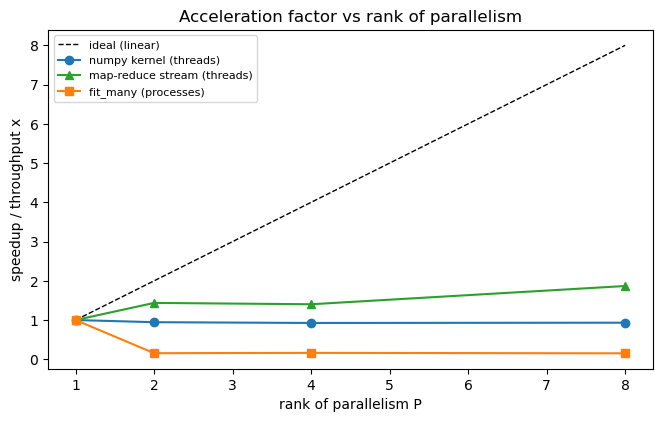

In [5]:
fig, ax = plt.subplots(figsize=(7.8, 4.4))
ax.plot(PS, PS, "k--", lw=1, label="ideal (linear)")
if kspeed:
    ax.plot(PS, [kspeed[P] for P in PS], "o-", color="tab:blue",
            label="numpy kernel (threads)")
ax.plot(PS, [mrspeed[P] for P in PS], "^-", color="tab:green",
        label="map-reduce stream (threads)")
ax.plot(PS, [fmspeed[P] for P in PS], "s-", color="tab:orange",
        label="fit_many (processes)")
ax.set_title("Acceleration factor vs rank of parallelism")
ax.set_xlabel("rank of parallelism P"); ax.set_ylabel("speedup / throughput x")
ax.legend(fontsize=8)
fig.savefig(FIG / "scaling.png", dpi=110, bbox_inches="tight")
plt.show()

## Reading it

- **The numpy kernel does not scale under threads.** With the compiled C kernel gone, the
  Simpson benchmark is a Python loop over `scipy.integrate.simpson`, which holds the GIL for
  the whole call; a thread pool cannot overlap it, and thread-pool overhead makes P>1 slightly
  slower than P=1. The clean parallelization win this leg used to report belonged to the
  removed compiled kernel, not to the numpy code that replaced it.
- The threaded **map-reduce** stream still scales before memory bandwidth saturates (its bulk
  numpy array ops do release the GIL, unlike the small-call Simpson loop above).
- Fine-grained **`fit_many`** fits are embarrassingly parallel in principle but here limited by
  per-task process overhead; they scale when the per-task work is coarse/heavy (batch the fits)
  rather than millisecond-sized.

The peak numbers for this run are printed below.

In [6]:
summary = pd.DataFrame({
    "numpy kernel (threads)": {"peak speedup x": max(kspeed.values()) if kspeed else float("nan")},
    "map-reduce stream (threads)": {"peak speedup x": max(mrspeed.values())},
    "fit_many (processes)": {"peak speedup x": max(fmspeed.values())},
}).T
summary

,peak speedup x
numpy kernel (threads),1.00
map-reduce stream (threads),1.87
fit_many (processes),1.00
